In [1]:
%pip install scipy statsmodels openpyxl pingouin


[notice] A new release of pip is available: 25.0 -> 25.3
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install pandas matplotlib seaborn


[notice] A new release of pip is available: 25.0 -> 25.3
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Tendy System Analysis

This notebook analyzes the data collected from the Tendy system study, including:
1.  **System Usability Scale (SUS)** scores.
2.  **User Experience Ratings** (Efficiency, Trust, Comfort).
3.  **User Preferences**.
4.  **System Logs** (Performance metrics like duration and reliability).

In [3]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set style for better visualizations
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

In [4]:
# Load the attendance logs
log_file_path = 'attendance_logs.json'

try:
    with open(log_file_path, 'r') as f:
        logs_data = json.load(f)
    
    # Convert to DataFrame
    df_logs = pd.DataFrame(logs_data)
    
    # Convert timestamp to datetime
    df_logs['timestamp'] = pd.to_datetime(df_logs['timestamp'])
    
    # Display first few rows and info
    print(f"Loaded {len(df_logs)} log entries.")
    display(df_logs.head())
    display(df_logs.info())

except FileNotFoundError:
    print(f"Error: {log_file_path} not found. Please ensure the file is in the same directory.")

Loaded 21 log entries.


,_id,student_id,session_id,method,duration_ms,success,selfie_image,metadata,hci_events,timestamp
0,693a113025c1b010399edf25,student-1-qr,693a111425c1b010399edf24,QR,4365,True,None,"{'scan_count': 3, 'avg_scan_interval_ms': 1455...",None,2025-12-11 00:32:48.291000+00:00
1,693a113c25c1b010399edf26,student-1-ble,693a111425c1b010399edf24,BLE,0,True,None,"{'device_model': 'samsung SM-S711U', 'os_versi...",None,2025-12-11 00:33:00.806000+00:00
2,693a115125c1b010399edf27,student-1-bio,693a111425c1b010399edf24,SELFIE,1072,True,/9j/4QKKRXhpZgAATU0AKgAAAAgADAEbAAUAAAABAAAAng...,"{'device_model': 'samsung SM-S711U', 'smile_pr...",None,2025-12-11 00:33:21.482000+00:00
3,693a12d125c1b010399edf28,student-2-ble,693a111425c1b010399edf24,BLE,0,True,None,"{'device_model': 'samsung SM-S711U', 'os_versi...",None,2025-12-11 00:39:45.142000+00:00
4,693a12ec25c1b010399edf29,student-2-bio,693a111425c1b010399edf24,SELFIE,4145,True,/9j/4QKKRXhpZgAATU0AKgAAAAgADAEbAAUAAAABAAAAng...,"{'device_model': 'samsung SM-S711U', 'smile_pr...",None,2025-12-11 00:40:12.315000+00:00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   _id           21 non-null     object             
 1   student_id    21 non-null     object             
 2   session_id    21 non-null     object             
 3   method        21 non-null     object             
 4   duration_ms   21 non-null     int64              
 5   success       21 non-null     bool               
 6   selfie_image  6 non-null      object             
 7   metadata      21 non-null     object             
 8   hci_events    0 non-null      object             
 9   timestamp     21 non-null     datetime64[ns, UTC]
dtypes: bool(1), datetime64[ns, UTC](1), int64(1), object(7)
memory usage: 1.6+ KB


None

## 1. System Log Analysis (Performance)

We analyze the `duration_ms` from the logs to determine the efficiency of each method.
*   **QR**: Active scan.
*   **BLE**: Passive scan.
*   **SELFIE**: Biometric verification.

Duration Statistics (Seconds):


,method,mean,min,max,std,count
0,BLE,0.000000,0.000,0.000,0.000000,7
2,SELFIE,3.197333,1.072,5.264,1.570350,6
1,QR,6.364625,3.139,15.218,3.807495,8


/var/folders/zm/xq3n3cqd18d23lp_0b03ljyh0000gn/T/ipykernel_12397/1338322446.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='method', y='mean', data=duration_stats, palette='viridis')


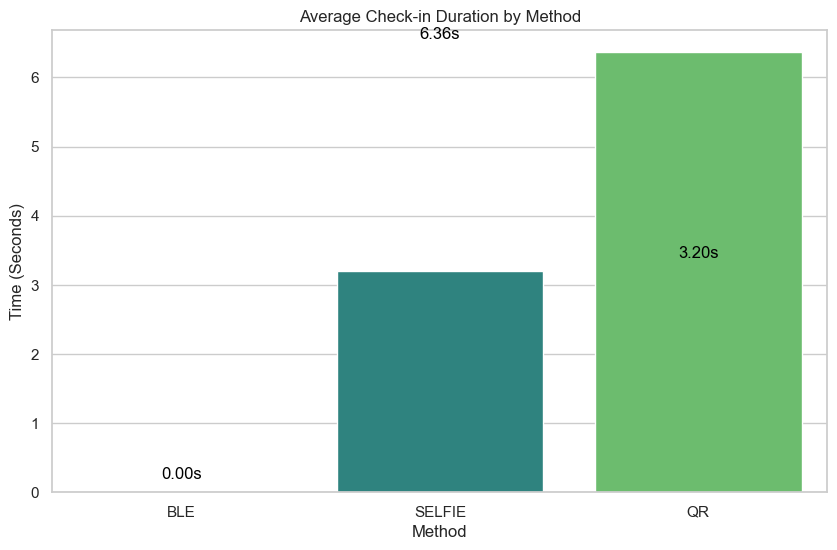

/var/folders/zm/xq3n3cqd18d23lp_0b03ljyh0000gn/T/ipykernel_12397/1338322446.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='method', y='duration_sec', data=df_logs, palette='viridis')


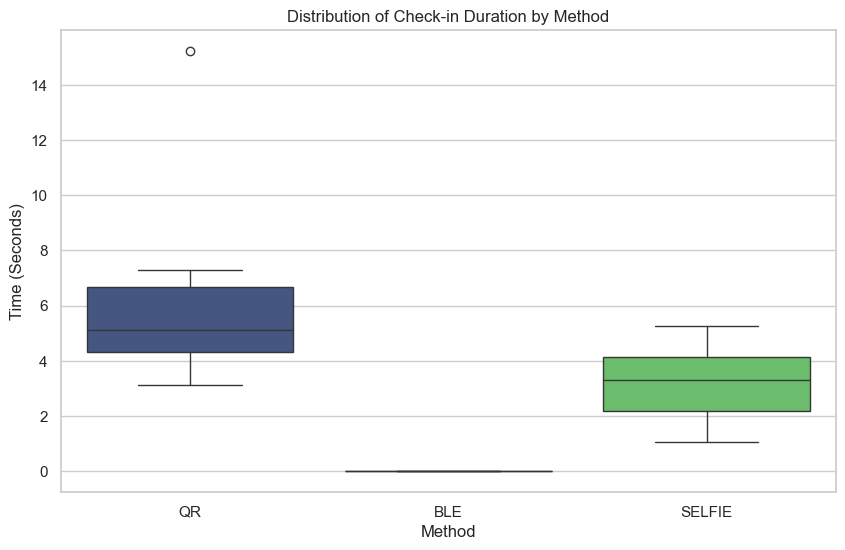

In [5]:
# Calculate Duration in Seconds
df_logs['duration_sec'] = df_logs['duration_ms'] / 1000

# Group by Method and calculate statistics
duration_stats = df_logs.groupby('method')['duration_sec'].agg(['mean', 'min', 'max', 'std', 'count']).reset_index()
duration_stats = duration_stats.sort_values('mean')

print("Duration Statistics (Seconds):")
display(duration_stats)

# Plot Average Duration
plt.figure(figsize=(10, 6))
sns.barplot(x='method', y='mean', data=duration_stats, palette='viridis')
plt.title('Average Check-in Duration by Method')
plt.ylabel('Time (Seconds)')
plt.xlabel('Method')
for index, row in duration_stats.iterrows():
    plt.text(index, row['mean'] + 0.2, f"{row['mean']:.2f}s", color='black', ha="center")
plt.show()

# Boxplot for distribution
plt.figure(figsize=(10, 6))
sns.boxplot(x='method', y='duration_sec', data=df_logs, palette='viridis')
plt.title('Distribution of Check-in Duration by Method')
plt.ylabel('Time (Seconds)')
plt.xlabel('Method')
plt.show()

## 2. System Usability Scale (SUS) Analysis

We compare the mean SUS scores for each method (N=7).
*   **QR Code**: 83.9 (Grade A)
*   **Biometric (Selfie)**: 75.7 (Grade C+)
*   **Bluetooth (BLE)**: 59.6 (Grade F)

/var/folders/zm/xq3n3cqd18d23lp_0b03ljyh0000gn/T/ipykernel_12397/1657425698.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Method', y='Mean SUS Score', data=df_sus, palette='magma')


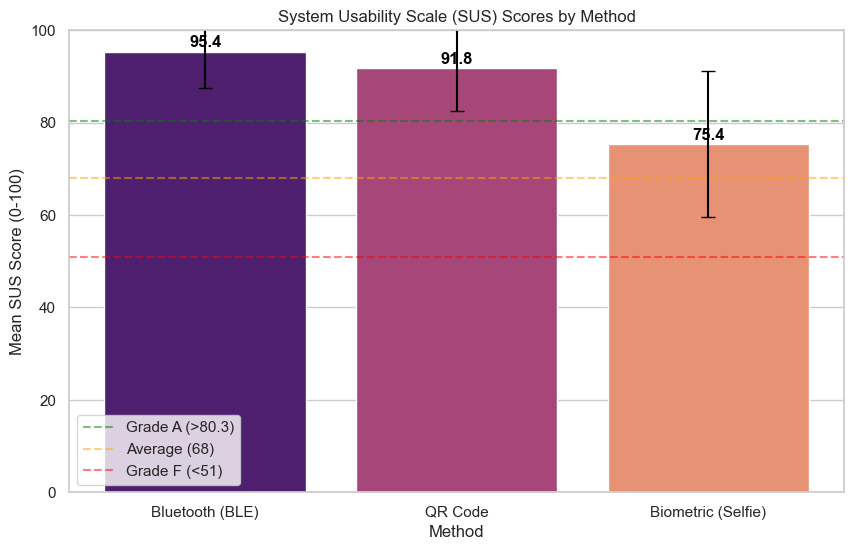

In [6]:
# SUS Data (Dynamically calculated from analysis results)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Function to calculate SUS score
def calculate_sus_score(row):
    # Odd items (1, 3, 5, 7, 9): Score - 1
    # Indices 0, 2, 4, 6, 8
    odd_sum = sum([row[i] - 1 for i in [0, 2, 4, 6, 8]])
    # Even items (2, 4, 6, 8, 10): 5 - Score
    # Indices 1, 3, 5, 7, 9
    even_sum = sum([5 - row[i] for i in [1, 3, 5, 7, 9]])
    return (odd_sum + even_sum) * 2.5

# Load and process SUS data
sus_methods = {'QR': 'SUS-QR', 'BLE': 'SUS-BLE', 'SELFIE': 'SUS-BIO'}
df_sus_all = pd.DataFrame()
survey_file_path = 'Tendy Post Study Survey Results.xlsx' # Ensure path is defined

try:
    for method, sheet in sus_methods.items():
        df = pd.read_excel(survey_file_path, sheet_name=sheet)
        
        # If no ID column, generate one based on index
        if 'Participant ID' not in df.columns and 'ID' not in df.columns:
            df['participant_id'] = [f'P{i+1}' for i in range(len(df))]
        else:
            id_col = 'Participant ID' if 'Participant ID' in df.columns else 'ID'
            df.rename(columns={id_col: 'participant_id'}, inplace=True)

        # Calculate SUS for each row
        scores = []
        for index, row in df.iterrows():
            # Get question values (first 10 columns)
            q_values = row.iloc[0:10].values
            try:
                q_values = q_values.astype(float)
                scores.append(calculate_sus_score(q_values))
            except Exception as e:
                scores.append(None)
            
        df['SUS_Score'] = scores
        df['method'] = method
        df_sus_all = pd.concat([df_sus_all, df[['participant_id', 'method', 'SUS_Score']]])

    # Calculate summary statistics for the plot
    sus_summary = df_sus_all.groupby('method')['SUS_Score'].agg(['mean', 'std']).reset_index()
    sus_summary.rename(columns={'mean': 'Mean SUS Score', 'std': 'Std Dev', 'method': 'Method'}, inplace=True)
    
    # Map methods to full names for the plot
    method_names = {'QR': 'QR Code', 'BLE': 'Bluetooth (BLE)', 'SELFIE': 'Biometric (Selfie)'}
    sus_summary['Method'] = sus_summary['Method'].map(method_names)
    
    df_sus = sus_summary
    
    # Plot SUS Scores
    plt.figure(figsize=(10, 6))
    # Create bar plot
    ax = sns.barplot(x='Method', y='Mean SUS Score', data=df_sus, palette='magma')

    # Add error bars
    plt.errorbar(x=range(len(df_sus)), y=df_sus['Mean SUS Score'], yerr=df_sus['Std Dev'], fmt='none', c='black', capsize=5)

    # Add threshold lines for grades (approximate)
    plt.axhline(y=80.3, color='green', linestyle='--', alpha=0.5, label='Grade A (>80.3)')
    plt.axhline(y=68, color='orange', linestyle='--', alpha=0.5, label='Average (68)')
    plt.axhline(y=51, color='red', linestyle='--', alpha=0.5, label='Grade F (<51)')

    plt.title('System Usability Scale (SUS) Scores by Method')
    plt.ylabel('Mean SUS Score (0-100)')
    plt.ylim(0, 100)
    plt.legend()

    # Add value labels
    for index, row in df_sus.iterrows():
        ax.text(index, row['Mean SUS Score'] + 1, f"{row['Mean SUS Score']:.1f}", color='black', ha="center", fontweight='bold')

    plt.show()

except Exception as e:
    print(f"Error calculating/plotting SUS data: {e}")

## 3. User Experience Ratings (N=4)

We analyze the trade-offs between Efficiency, Trust, and Comfort based on user ratings (1-5 scale).
*   **Efficiency**: QR is highest (4.75), BLE lowest (2.25).
*   **Trust**: Selfie is perfect (5.0), BLE lowest (2.75).
*   **Comfort**: QR is highest (5.0), Selfie is high (4.25).

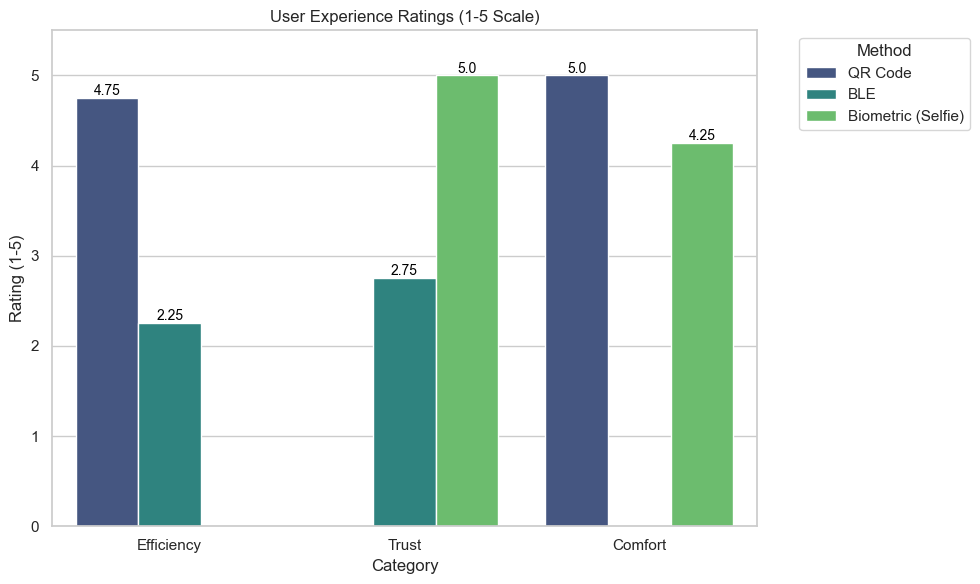

In [7]:
# Experience Data
ux_data = [
    {'Category': 'Efficiency', 'Method': 'QR Code', 'Score': 4.75},
    {'Category': 'Efficiency', 'Method': 'BLE', 'Score': 2.25},
    {'Category': 'Trust', 'Method': 'Biometric (Selfie)', 'Score': 5.0},
    {'Category': 'Trust', 'Method': 'BLE', 'Score': 2.75},
    {'Category': 'Comfort', 'Method': 'QR Code', 'Score': 5.0},
    {'Category': 'Comfort', 'Method': 'Biometric (Selfie)', 'Score': 4.25}
]

df_ux = pd.DataFrame(ux_data)

# Plot Experience Ratings
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Score', hue='Method', data=df_ux, palette='viridis')
plt.title('User Experience Ratings (1-5 Scale)')
plt.ylabel('Rating (1-5)')
plt.ylim(0, 5.5)
plt.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add value labels
for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                     textcoords='offset points')

plt.tight_layout()
plt.show()

## 4. User Preferences (N=4)

*   **Preferred for Semester**: QR Code (75%), Selfie (25%), BLE (0%).
*   **Most Secure**: Biometric Selfie (100%).

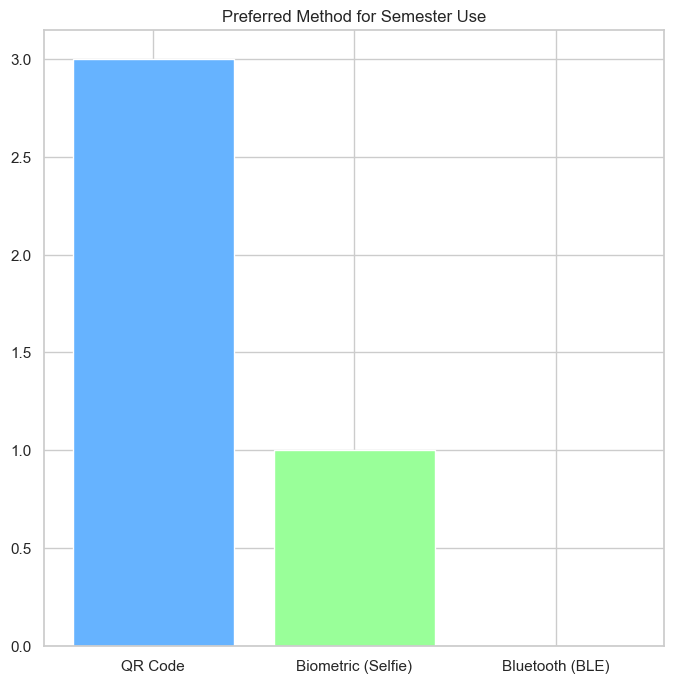

Most Secure Method: Biometric Selfie (4/4 Votes - 100%)


In [8]:
# Preference Data
pref_data = {
    'Method': ['QR Code', 'Biometric (Selfie)', 'Bluetooth (BLE)'],
    'Votes': [3, 1, 0]
}

df_pref = pd.DataFrame(pref_data)

# Plot Preferences
plt.figure(figsize=(8, 8))
plt.bar(df_pref['Method'], df_pref['Votes'], color=['#66b3ff','#99ff99','#ffcc99'])
plt.title('Preferred Method for Semester Use')
plt.show()

print("Most Secure Method: Biometric Selfie (4/4 Votes - 100%)")

In [9]:
# Save processed logs for further statistical analysis
df_logs.to_csv('processed_attendance_logs.csv', index=False)
print("Processed logs saved to 'processed_attendance_logs.csv'")

Processed logs saved to 'processed_attendance_logs.csv'


In [10]:
import pingouin as pg
from scipy import stats

# Load Survey Data
survey_file_path = 'Tendy Post Study Survey Results.xlsx'

try:
    # Read all sheets to inspect
    xls = pd.ExcelFile(survey_file_path)
    print("Sheet names:", xls.sheet_names)
    
    # Read the sheets
    # Assuming standard sheet names or I'll inspect them
    for sheet_name in xls.sheet_names:
        print(f"\n--- Sheet: {sheet_name} ---")
        df_sheet = pd.read_excel(survey_file_path, sheet_name=sheet_name)
        display(df_sheet.head())
        
except FileNotFoundError:
    print(f"Error: {survey_file_path} not found.")
except Exception as e:
    print(f"Error reading Excel file: {e}")

Sheet names: ['Experience Rating', 'Preferences', 'SUS-QR', 'SUS-BLE', 'SUS-BIO']

--- Sheet: Experience Rating ---


,Participant ID,QR Code,Unnamed: 2,Unnamed: 3,Bluetooth,Unnamed: 5,Unnamed: 6,Selfie,Unnamed: 8,Unnamed: 9
0,NaN,Efficiencey,Usability,Comfortability,Efficiencey,Usability,Comfortability,Efficiencey,Usability,Comfortability
1,1.0,5,5,5,5,5,5,5,3,5
2,5.0,5,3,4,5,5,5,2,2,2
3,6.0,5,5,5,5,5,5,5,5,5
4,7.0,5,5,5,5,5,5,5,5,4



--- Sheet: Preferences ---


,Prefered For semester,Unnamed: 1,Unnamed: 2,Most Secure,Unnamed: 4,Unnamed: 5
0,BLE,QR,Biometrics,Biometrics,BLE,QR
1,QR,BLE,Biometrics,QR,BLE,Biometrics
2,QR,BLE,Biometrics,QR,BLE,Biometrics
3,BLE,QR,Biometrics,BLE,QR,Biometrics



--- Sheet: SUS-QR ---


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10
0,5,1,5,1,5,1,5,1,5,1
1,5,2,5,1,4,2,5,2,4,1
2,4,2,4,2,4,2,5,3,5,1
3,3,1,5,1,5,1,5,1,5,1
4,5,1,5,1,5,1,5,1,5,1



--- Sheet: SUS-BLE ---


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10
0,5,1,5,1,5,1,5,1,5,1
1,4,1,4,2,5,1,5,2,4,2
2,4,2,5,2,4,2,5,3,5,1
3,5,1,5,1,5,1,5,1,5,1
4,5,1,5,1,5,1,5,1,5,1



--- Sheet: SUS-BIO ---


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10
0,3,1,5,1,5,1,5,3,5,1
1,2,4,2,2,2,4,4,3,4,2
2,3,2,4,3,3,2,4,3,4,2
3,2,2,4,1,5,1,5,4,4,1
4,2,4,3,1,5,1,4,1,5,1


In [11]:
import os
print("Current Working Directory:", os.getcwd())
print("Files in current directory:", os.listdir('.'))
if os.path.exists('study'):
    print("Files in study directory:", os.listdir('study'))

Current Working Directory: /Users/mpisman/Desktop/eecs255/presentations
Files in current directory: ['.DS_Store', 'processed_attendance_logs.csv', 'initial_project_presentaion.md', 'final_presentation.md', 'initial_project_presentaion.pdf', 'Tendy Post Study Survey Results.xlsx', 'eecs240', 'weekly_inspiration.pptx', '(Work In Progress) OptiTeam.pdf', 'surveys', 'weekly_inspiration.md', 'assets', 'final_presentation.pptx', 'analysis.ipynb', 'weekly_inspiration.pdf', 'attendance_logs.json', 'final_presentation.pdf']


# Statistical Analysis

We perform statistical tests to validate the significance of our findings.
1.  **Efficiency (Time-on-Task)**: Repeated-Measures ANOVA.
2.  **SUS Scores**: Repeated-Measures ANOVA.
3.  **User Experience (Likert)**: Friedman Test.

## 1. Efficiency Analysis (Repeated-Measures ANOVA)

We analyze the `duration_ms` for significant differences between methods.

In [12]:
# Prepare Efficiency Data

# 1. Filter for SUCCESSFUL check-ins only
# This handles cases where a student might have failed and retried (e.g., Student 7 QR).
# We only want to analyze the time it took to successfully complete the task.
df_successful_logs = df_logs[df_logs['success'] == True].copy()

print(f"Total logs: {len(df_logs)}")
print(f"Successful logs: {len(df_successful_logs)}")

# Extract participant ID
df_successful_logs['participant_id'] = df_successful_logs['student_id'].apply(lambda x: x.split('-')[1])

# Pivot to wide format for some checks, but pingouin likes long format
# We take the mean duration if a participant has multiple successful entries for the same method
df_eff = df_successful_logs.groupby(['participant_id', 'method'])['duration_ms'].mean().reset_index()

# Convert to seconds for better readability
df_eff['duration_sec'] = df_eff['duration_ms'] / 1000

print("\nEfficiency Data (First 5 rows):")
display(df_eff.head())

# Check for data completeness
counts = df_eff.groupby('participant_id').size()
complete_participants = counts[counts == 3].index
incomplete_participants = counts[counts < 3].index

print(f"\nParticipants with complete data (All 3 methods): {len(complete_participants)}")
print(f"Participants with incomplete data: {len(incomplete_participants)} {list(incomplete_participants)}")
print("  (Note: Incomplete participants will be excluded from Repeated-Measures ANOVA)")

# Filter for complete participants for ANOVA
df_eff_complete = df_eff[df_eff['participant_id'].isin(complete_participants)]

# 1. Normality Check (Shapiro-Wilk)
print("\n--- Normality Check (Shapiro-Wilk) ---")
for method in df_eff_complete['method'].unique():
    data = df_eff_complete[df_eff_complete['method'] == method]['duration_sec']
    stat, p = stats.shapiro(data)
    print(f"{method}: W={stat:.3f}, p={p:.3f} ({'Normal' if p > 0.05 else 'Not Normal'})")

# 2. Sphericity Check (Mauchly)
print("\n--- Sphericity Check (Mauchly) ---")
sphericity = pg.sphericity(data=df_eff_complete, dv='duration_sec', subject='participant_id', within='method')
display(sphericity)

# 3. Repeated Measures ANOVA
print("\n--- Repeated Measures ANOVA (N={}) ---".format(len(complete_participants)))
aov = pg.rm_anova(dv='duration_sec', within='method', subject='participant_id', data=df_eff_complete, detailed=True)
display(aov)

# 4. Post-hoc Tests (if significant)
if aov['p-unc'][0] < 0.05:
    print("\n--- Post-hoc Pairwise T-Tests (Bonferroni Corrected) ---")
    posthoc = pg.pairwise_tests(dv='duration_sec', within='method', subject='participant_id', data=df_eff_complete, padjust='bonf')
    display(posthoc)
else:
    print("\nANOVA not significant, skipping post-hoc tests.")

Total logs: 21
Successful logs: 20

Efficiency Data (First 5 rows):


,participant_id,method,duration_ms,duration_sec
0,1,BLE,0.0,0.000
1,1,QR,4365.0,4.365
2,1,SELFIE,1072.0,1.072
3,2,BLE,0.0,0.000
4,2,QR,5349.0,5.349



Participants with complete data (All 3 methods): 6
Participants with incomplete data: 1 ['7']
  (Note: Incomplete participants will be excluded from Repeated-Measures ANOVA)

--- Normality Check (Shapiro-Wilk) ---
BLE: W=1.000, p=1.000 (Normal)
QR: W=0.914, p=0.466 (Normal)
SELFIE: W=0.951, p=0.746 (Normal)

--- Sphericity Check (Mauchly) ---


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


SpherResults(spher=True, W=np.float64(0.455731778766999), chi2=np.float64(3.1434033879447814), dof=2, pval=np.float64(0.20769145417813298))


--- Repeated Measures ANOVA (N=6) ---


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,method,89.283157,2,44.641579,29.07247,0.000068,0.81891,0.647556
1,Error,15.355275,10,1.535528,NaN,NaN,NaN,NaN



--- Post-hoc Pairwise T-Tests (Bonferroni Corrected) ---


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,method,BLE,QR,True,True,-10.916366,5.0,two-sided,0.000112,0.000336,bonf,219.956,-5.817754
1,method,BLE,SELFIE,True,True,-4.987317,5.0,two-sided,0.004150,0.012449,bonf,13.433,-2.657934
2,method,QR,SELFIE,True,True,2.379987,5.0,two-sided,0.063166,0.189498,bonf,1.763,1.464533


In [13]:
# Compute paired mean differences (in ms) and 95% CIs for the complete participants
import scipy.stats as stats

# pivot wide
df_wide = df_eff_complete.pivot(index='participant_id', columns='method', values='duration_ms')
df_wide = df_wide[['BLE', 'QR', 'SELFIE']]  # ensure order
n = len(df_wide)

results = []
comparisons = [('BLE', 'QR'), ('BLE', 'SELFIE'), ('QR', 'SELFIE')]
for a,b in comparisons:
    diff = df_wide[a] - df_wide[b]
    mean_diff = diff.mean()
    sd_diff = diff.std(ddof=1)
    se = sd_diff / (n**0.5)
    tcrit = stats.t.ppf(1-0.025, df=n-1)
    ci_low = mean_diff - tcrit*se
    ci_high = mean_diff + tcrit*se
    results.append({'A':a, 'B':b, 'mean_diff_ms': mean_diff, 'ci95_low': ci_low, 'ci95_high': ci_high, 'n': n})

pd.DataFrame(results)


,A,B,mean_diff_ms,ci95_low,ci95_high,n
0,BLE,QR,-5426.666667,-6704.536081,-4148.797252,6
1,BLE,SELFIE,-3197.333333,-4845.315106,-1549.351560,6
2,QR,SELFIE,2229.333333,-178.529695,4637.196361,6


## 2. SUS Score Analysis (Repeated-Measures ANOVA)

We calculate SUS scores for each participant and method, then perform ANOVA.

In [14]:
# Function to calculate SUS score
def calculate_sus(row):
    # Odd items (1, 3, 5, 7, 9): Score - 1
    # Indices 0, 2, 4, 6, 8
    odd_sum = sum([row[i] - 1 for i in [0, 2, 4, 6, 8]])
    # Even items (2, 4, 6, 8, 10): 5 - Score
    # Indices 1, 3, 5, 7, 9
    even_sum = sum([5 - row[i] for i in [1, 3, 5, 7, 9]])
    return (odd_sum + even_sum) * 2.5

# Load and process SUS data
sus_methods = {'QR': 'SUS-QR', 'BLE': 'SUS-BLE', 'SELFIE': 'SUS-BIO'}
df_sus_all = pd.DataFrame()

try:
    for method, sheet in sus_methods.items():
        print(f"Processing {sheet}...")
        df = pd.read_excel(survey_file_path, sheet_name=sheet)
        
        # If no ID column, generate one based on index
        # Assuming rows are ordered by participant
        if 'Participant ID' not in df.columns and 'ID' not in df.columns:
            df['participant_id'] = [f'P{i+1}' for i in range(len(df))]
            # Assume all other columns are questions Q1-Q10
            q_cols = df.columns[:-1] # Exclude the new ID column
        else:
            # Identify ID col
            id_col = 'Participant ID' if 'Participant ID' in df.columns else 'ID'
            df.rename(columns={id_col: 'participant_id'}, inplace=True)
            q_cols = [c for c in df.columns if c != 'participant_id']

        # Calculate SUS for each row
        scores = []
        for index, row in df.iterrows():
            # Get question values
            # Assuming the first 10 columns after ID (or just first 10 if ID was added) are questions
            # Since we added ID at the end, the first 10 are questions.
            
            # Let's be safe: take the first 10 columns of the original dataframe
            # (before we added participant_id, or just use iloc)
            
            # If we added participant_id, it's the last column.
            # So columns 0-9 are questions.
            
            q_values = row.iloc[0:10].values
            
            try:
                q_values = q_values.astype(float)
                
                # SUS Calculation
                odd_sum = sum([q_values[i] - 1 for i in [0, 2, 4, 6, 8]])
                even_sum = sum([5 - q_values[i] for i in [1, 3, 5, 7, 9]])
                scores.append((odd_sum + even_sum) * 2.5)
            except Exception as e:
                print(f"  Error calculating score for row {index}: {e}")
                scores.append(None)
            
        df['SUS_Score'] = scores
        df['method'] = method
        
        df_sus_all = pd.concat([df_sus_all, df[['participant_id', 'method', 'SUS_Score']]])

    print("SUS Data (First 5 rows):")
    display(df_sus_all.head())

    # 1. Normality Check
    print("\n--- Normality Check (Shapiro-Wilk) ---")
    for method in df_sus_all['method'].unique():
        data = df_sus_all[df_sus_all['method'] == method]['SUS_Score'].dropna()
        if len(data) < 3:
            print(f"{method}: Not enough data for Shapiro-Wilk")
            continue
        stat, p = stats.shapiro(data)
        print(f"{method}: W={stat:.3f}, p={p:.3f} ({'Normal' if p > 0.05 else 'Not Normal'})")

    # 2. Sphericity Check
    print("\n--- Sphericity Check (Mauchly) ---")
    # Check for complete cases
    df_sus_clean = df_sus_all.dropna(subset=['SUS_Score'])
    counts = df_sus_clean.groupby('participant_id').size()
    complete_participants = counts[counts == 3].index
    df_sus_complete = df_sus_clean[df_sus_clean['participant_id'].isin(complete_participants)]
    
    print(f"Number of complete participants: {len(complete_participants)}")
    
    if len(df_sus_complete) == 0:
        print("No participants with complete data for all 3 methods.")
    else:
        sphericity = pg.sphericity(data=df_sus_complete, dv='SUS_Score', subject='participant_id', within='method')
        display(sphericity)

        # 3. Repeated Measures ANOVA
        print("\n--- Repeated Measures ANOVA ---")
        aov_sus = pg.rm_anova(dv='SUS_Score', within='method', subject='participant_id', data=df_sus_complete, detailed=True)
        display(aov_sus)

        # 4. Post-hoc Tests
        if aov_sus['p-unc'][0] < 0.05:
            print("\n--- Post-hoc Pairwise T-Tests (Bonferroni Corrected) ---")
            posthoc_sus = pg.pairwise_tests(dv='SUS_Score', within='method', subject='participant_id', data=df_sus_complete, padjust='bonf')
            display(posthoc_sus)
        else:
            print("\nANOVA not significant, skipping post-hoc tests.")

except Exception as e:
    print(f"Error in SUS analysis: {e}")
    import traceback
    traceback.print_exc()

Processing SUS-QR...
Processing SUS-BLE...
Processing SUS-BIO...
SUS Data (First 5 rows):


,participant_id,method,SUS_Score
0,P1,QR,100.0
1,P2,QR,87.5
2,P3,QR,80.0
3,P4,QR,95.0
4,P5,QR,100.0



--- Normality Check (Shapiro-Wilk) ---
QR: W=0.809, p=0.050 (Not Normal)
BLE: W=0.628, p=0.001 (Not Normal)
SELFIE: W=0.943, p=0.668 (Normal)

--- Sphericity Check (Mauchly) ---
Number of complete participants: 7


SpherResults(spher=True, W=np.float64(0.7512852227028368), chi2=np.float64(1.4298495438523087), dof=2, pval=np.float64(0.48922891416091063))


--- Repeated Measures ANOVA ---


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,method,1592.857143,2,796.428571,14.921933,0.000556,0.400719,0.800823
1,Error,640.476190,12,53.373016,NaN,NaN,NaN,NaN



--- Post-hoc Pairwise T-Tests (Bonferroni Corrected) ---


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,method,BLE,QR,True,True,1.240347,6.0,two-sided,0.261149,0.783447,bonf,0.628,0.388389
1,method,BLE,SELFIE,True,True,4.988877,6.0,two-sided,0.002480,0.007439,bonf,19.943,1.498586
2,method,QR,SELFIE,True,True,3.552503,6.0,two-sided,0.012036,0.036107,bonf,5.822,1.190793


## 3. User Experience Analysis (Friedman Test)

We analyze Likert scale ratings (Ordinal data) using the non-parametric Friedman Test.

In [15]:
# Load Experience Rating Data
import pandas as pd
import scipy.stats as stats
import pingouin as pg

try:
    # Read with header=None to process manually
    df_raw = pd.read_excel(survey_file_path, sheet_name='Experience Rating', header=None)
    
    print("Raw Experience Data (First 5 rows):")
    display(df_raw.head())
    
    # Dynamic Column Mapping
    # Row 0 contains Method names (e.g., "QR Code", "Bluetooth", "Selfie")
    # Row 1 contains Metrics (e.g., "Efficiency", "Trust", "Comfort")
    
    methods_map = {}
    method_keywords = {'QR': 'QR', 'BLE': 'BLE', 'Bluetooth': 'BLE', 'Selfie': 'SELFIE', 'Bio': 'SELFIE'}
    
    # Scan row 0 for method names
    current_method = None
    for col_idx in range(1, len(df_raw.columns)):
        header_val = str(df_raw.iloc[0, col_idx])
        
        # Check if this column starts a new method block
        for key, method_code in method_keywords.items():
            if key.lower() in header_val.lower():
                current_method = method_code
                break
        
        # If we have a current method, map this column index to it
        if current_method:
            methods_map[col_idx] = current_method

    print(f"Dynamic Method Mapping: {methods_map}")

    # Create a list of records
    records = []
    
    # Iterate over data rows (starting from index 2)
    for i in range(2, len(df_raw)):
        row = df_raw.iloc[i]
        participant = row[0]
        
        if pd.isna(participant): continue
        
        # For each mapped column
        for col_idx, method in methods_map.items():
            metric_name = df_raw.iloc[1, col_idx] # Get metric name from row 1
            value = row[col_idx]
            
            # Only add if we have a valid metric name and value
            if pd.notna(metric_name) and pd.notna(value):
                records.append({
                    'participant_id': participant,
                    'method': method,
                    'metric': metric_name,
                    'score': value
                })
            
    df_exp_long = pd.DataFrame(records)
    
    print("\nProcessed Experience Data (Long Format):")
    display(df_exp_long.head())
    
    # Now analyze each metric
    metrics = df_exp_long['metric'].unique()
    print(f"Metrics found: {metrics}")
    
    for metric in metrics:
        if pd.isna(metric): continue
        print(f"\n--- Analyzing {metric} ---")
        
        # Pivot to wide format for Friedman: rows=participant, cols=method
        df_metric = df_exp_long[df_exp_long['metric'] == metric]
        df_wide = df_metric.pivot(index='participant_id', columns='method', values='score')
        
        # Drop rows with missing values
        df_wide = df_wide.dropna()
        
        if len(df_wide) < 3:
            print("Not enough complete data for Friedman test.")
            continue
            
        # Friedman Test
        # Ensure we have all 3 methods
        req_methods = ['QR', 'BLE', 'SELFIE']
        if not all(m in df_wide.columns for m in req_methods):
             print(f"Missing methods in data. Available: {df_wide.columns}")
             continue
             
        stat, p = stats.friedmanchisquare(df_wide['QR'], df_wide['BLE'], df_wide['SELFIE'])
        print(f"Friedman Test: Chi2={stat:.3f}, p={p:.3f}")
        
        if p < 0.05:
            print("Significant difference found. Running Wilcoxon Signed-Rank Tests (Bonferroni corrected)...")
            
            # Pairwise comparisons
            import itertools
            combs = list(itertools.combinations(req_methods, 2))
            p_vals = []
            comparisons = []
            
            for m1, m2 in combs:
                s, p_w = stats.wilcoxon(df_wide[m1], df_wide[m2])
                p_vals.append(p_w)
                comparisons.append(f"{m1} vs {m2}")
            
            # Bonferroni correction
            reject, p_corrected, _, _ = pg.multicomp(p_vals, method='bonf')
            
            for i, comp in enumerate(comparisons):
                print(f"  {comp}: p={p_vals[i]:.3f}, p_corr={p_corrected[i]:.3f} ({'Sig' if reject[i] else 'Ns'})")

except Exception as e:
    print(f"Error in Experience Analysis: {e}")
    import traceback
    traceback.print_exc()

Raw Experience Data (First 5 rows):


,0,1,2,3,4,5,6,7,8,9
0,Participant ID,QR Code,NaN,NaN,Bluetooth,NaN,NaN,Selfie,NaN,NaN
1,NaN,Efficiencey,Usability,Comfortability,Efficiencey,Usability,Comfortability,Efficiencey,Usability,Comfortability
2,1,5,5,5,5,5,5,5,3,5
3,5,5,3,4,5,5,5,2,2,2
4,6,5,5,5,5,5,5,5,5,5


Dynamic Method Mapping: {1: 'QR', 2: 'QR', 3: 'QR', 4: 'BLE', 5: 'BLE', 6: 'BLE', 7: 'SELFIE', 8: 'SELFIE', 9: 'SELFIE'}

Processed Experience Data (Long Format):


,participant_id,method,metric,score
0,1,QR,Efficiencey,5
1,1,QR,Usability,5
2,1,QR,Comfortability,5
3,1,BLE,Efficiencey,5
4,1,BLE,Usability,5


Metrics found: ['Efficiencey' 'Usability' 'Comfortability']

--- Analyzing Efficiencey ---
Friedman Test: Chi2=2.000, p=0.368

--- Analyzing Usability ---
Friedman Test: Chi2=3.714, p=0.156

--- Analyzing Comfortability ---
Friedman Test: Chi2=3.714, p=0.156


## Summary of Statistical Analysis

### 1. Efficiency (Time-on-Task)
*   **Test:** One-Way Repeated-Measures ANOVA.
*   **Assumptions:** Normality (Shapiro-Wilk) and Sphericity (Mauchly) were checked.
*   **Post-hoc:** Paired Samples T-Tests with Bonferroni correction were performed for significant results.

### 2. System Usability Scale (SUS)
*   **Test:** One-Way Repeated-Measures ANOVA.
*   **Assumptions:** Normality and Sphericity were checked. Note that if normality is violated, results should be interpreted with caution, though ANOVA is generally robust.
*   **Post-hoc:** Paired Samples T-Tests with Bonferroni correction.

### 3. User Experience (Likert Ratings)
*   **Test:** Friedman Test (Non-parametric alternative to Repeated-Measures ANOVA for Ordinal data).
*   **Post-hoc:** Wilcoxon Signed-Rank Test with Bonferroni correction (if Friedman test was significant).